# RQ3: Cluster-Level Robustness for Sparse Suburban Stations

## Research Question
How does community aggregation affect sparse and suburban station performance versus station-level modeling?

## Hypothesis
H3: Community aggregation improves robustness for sparse/suburban demand slices relative to station aggregation.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import (
    HEADLINE_CONTRAST_BY_RQ,
    PRIMARY_COHORT_BY_RQ,
    canon_graph_set,
    cohort_station_indices,
    load_rq_inference_geo,
    optional_csv,
    paired_station_wmape_diff,
    relative_change,
    require_csv,
)

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

c:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Statistical inference (Methods)

Hypothesis tests use paired per-station test WMAPE (`rq_runner/rq_hypothesis_tests.csv`), Holm-adjusted within each RQ×cohort, α = 0.05, two-sided. **RQ3** contrasts pair **station** graph_propagation with **broadcast** community predictions evaluated on station actuals (not native community-space errors). See [docs/statistical_inference_rq.md](../docs/statistical_inference_rq.md).


### RQ3 hypothesis tests
**Primary cohort (pre-specified)**: `sparse_espoo` — `is_primary_cohort` marks those rows. **train_eval** robustness CSV is model-vs-reference on one graph set; **rq_hypothesis_tests** are station vs broadcast-community contrasts (see docs).

,cohort,contrast,H0,mean_delta,ci_lower,ci_upper,p_value,p_holm,reject_H0,n_stations_used,is_primary_cohort
7,all,station_vs_community_DE_DC,Mean paired station test WMAPE difference (sta...,-193.215527,-217.681250,-172.509561,0.0001,0.0002,True,446,False
6,all,station_vs_community_SD_DE_DC_ATD,Mean paired station test WMAPE difference (sta...,-193.273348,-217.447060,-173.261098,0.0001,0.0002,True,446,False
39,dense,station_vs_community_DE_DC,Mean paired station test WMAPE difference (sta...,-141.186404,-152.919468,-129.404373,0.0001,0.0002,True,334,False
38,dense,station_vs_community_SD_DE_DC_ATD,Mean paired station test WMAPE difference (sta...,-141.242342,-153.078908,-129.645686,0.0001,0.0002,True,334,False
23,espoo,station_vs_community_DE_DC,Mean paired station test WMAPE difference (sta...,-171.683074,-193.594061,-150.419242,0.0001,0.0002,True,103,False
22,espoo,station_vs_community_SD_DE_DC_ATD,Mean paired station test WMAPE difference (sta...,-171.755614,-193.594273,-149.259548,0.0001,0.0002,True,103,False
15,helsinki,station_vs_community_DE_DC,Mean paired station test WMAPE difference (sta...,-199.681540,-229.096270,-173.535075,0.0001,0.0002,True,343,False
14,helsinki,station_vs_community_SD_DE_DC_ATD,Mean paired station test WMAPE difference (sta...,-199.734941,-233.300618,-173.712077,0.0001,0.0002,True,343,False
31,sparse,station_vs_community_DE_DC,Mean paired station test WMAPE difference (sta...,-348.373803,-437.796818,-280.255669,0.0001,0.0002,True,112,False
30,sparse,station_vs_community_SD_DE_DC_ATD,Mean paired station test WMAPE difference (sta...,-348.437238,-437.042365,-280.017100,0.0001,0.0002,True,112,False


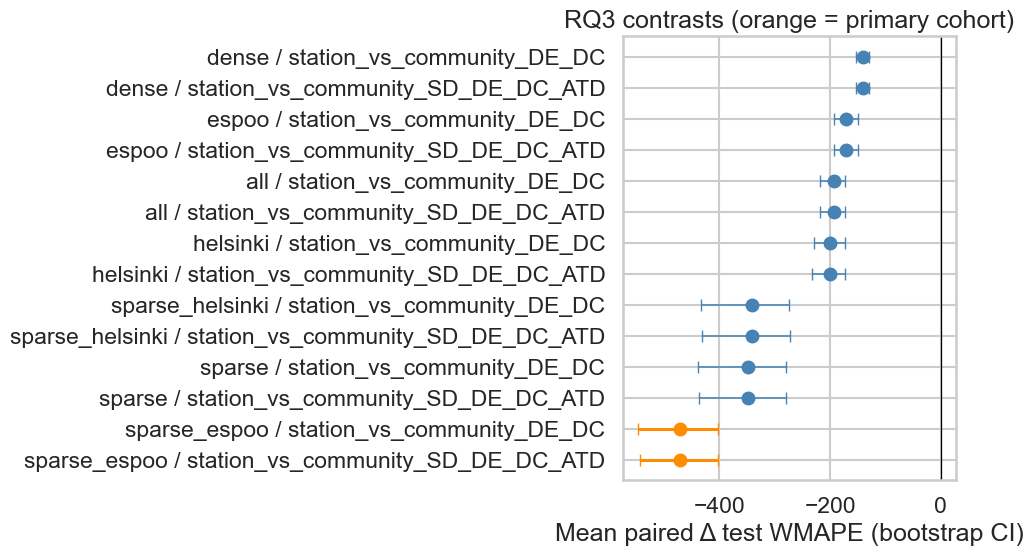

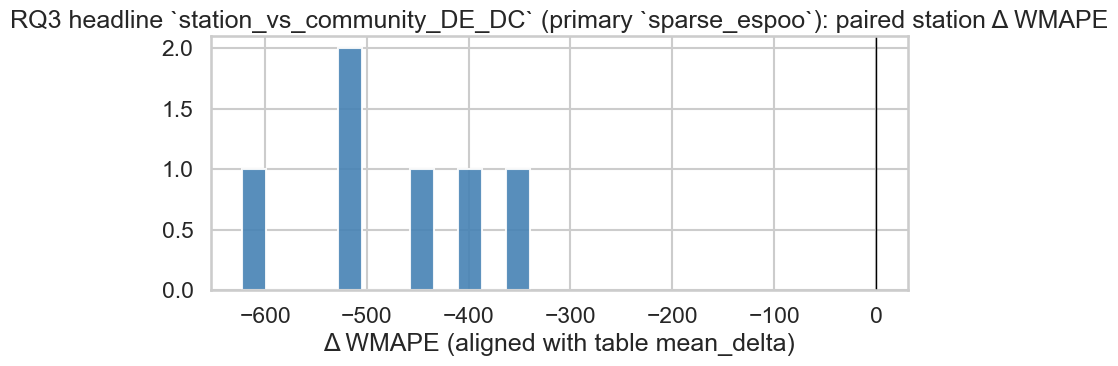

In [2]:
from IPython.display import Markdown, display

_hypothesis_path = ARTIFACT_ROOT / 'rq_runner' / 'rq_hypothesis_tests.csv'
if not _hypothesis_path.is_file():
    raise FileNotFoundError(
        f'Missing {_hypothesis_path}. Run python -m scripts.experiments.rq_hypothesis_tests --output-dir data/artifacts/experiments/rq_runner after experiment_runners.'
    )
_rqh = pd.read_csv(_hypothesis_path)
_RQ = 'RQ3'
_rq3h = _rqh[_rqh['rq'] == _RQ].sort_values(['cohort', 'contrast']).copy()
_pc = PRIMARY_COHORT_BY_RQ[_RQ]
_rq3h['is_primary_cohort'] = _rq3h['cohort'] == _pc
display(
    Markdown(
        f'### {_RQ} hypothesis tests\n'
        f'**Primary cohort (pre-specified)**: `{_pc}` — `is_primary_cohort` marks those rows. '
        '**train_eval** robustness CSV is model-vs-reference on one graph set; **rq_hypothesis_tests** are station vs broadcast-community contrasts (see docs).'
    )
)
_cols = [
    'cohort',
    'contrast',
    'mean_delta',
    'ci_lower',
    'ci_upper',
    'p_value',
    'p_holm',
    'reject_H0',
    'n_stations_used',
    'is_primary_cohort',
]
if 'H0' in _rq3h.columns:
    _cols = [
        'cohort',
        'contrast',
        'H0',
        'mean_delta',
        'ci_lower',
        'ci_upper',
        'p_value',
        'p_holm',
        'reject_H0',
        'n_stations_used',
        'is_primary_cohort',
    ]
display(_rq3h[_cols])

_df = _rq3h[np.isfinite(_rq3h['mean_delta'])].copy()
if not _df.empty:
    _df['label'] = _df['cohort'].astype(str) + ' / ' + _df['contrast'].astype(str)
    _df = _df.sort_values('mean_delta').reset_index(drop=True)
    y = np.arange(len(_df))
    plt.figure(figsize=(10, max(4.0, 0.35 * len(_df) + 1.0)))
    for i, row in _df.iterrows():
        color = 'darkorange' if row['is_primary_cohort'] else 'steelblue'
        elw = 2.2 if row['is_primary_cohort'] else 1.1
        lo = row['mean_delta'] - row['ci_lower']
        hi = row['ci_upper'] - row['mean_delta']
        plt.errorbar(
            [row['mean_delta']],
            [i],
            xerr=[[lo], [hi]],
            fmt='o',
            capsize=4,
            color=color,
            ecolor=color,
            elinewidth=elw,
        )
    plt.axvline(0, color='black', linewidth=0.9)
    plt.yticks(y, _df['label'])
    plt.xlabel('Mean paired Δ test WMAPE (bootstrap CI)')
    plt.title(f'{_RQ} contrasts (orange = primary cohort)')
    plt.tight_layout()
    plt.show()

_head = HEADLINE_CONTRAST_BY_RQ[_RQ]
_row = _rq3h[(_rq3h['cohort'] == _pc) & (_rq3h['contrast'] == _head)]
_exp = {'experiment_a', 'experiment_b'}
if len(_row) == 1 and _exp <= set(_row.columns):
    try:
        geo = load_rq_inference_geo(ARTIFACT_ROOT)
        idx = cohort_station_indices(
            _pc,
            train_csv=geo['train_csv'],
            graph_dir=geo['graph_dir'],
            stations_dir=geo['stations_dir'],
            sparse_quantile=geo['sparse_quantile'],
        )
        diff = paired_station_wmape_diff(
            geo['scores_dir'],
            str(_row['experiment_a'].iloc[0]),
            str(_row['experiment_b'].iloc[0]),
            idx,
        )
        if diff.size:
            plt.figure(figsize=(8, 4))
            nb = min(45, max(12, int(np.sqrt(diff.size)) * 3))
            plt.hist(diff, bins=nb, color='steelblue', edgecolor='white', alpha=0.9)
            plt.axvline(0, color='black', linewidth=1)
            plt.title(f'{_RQ} headline `{_head}` (primary `{_pc}`): paired station Δ WMAPE')
            plt.xlabel('Δ WMAPE (aligned with table mean_delta)')
            plt.tight_layout()
            plt.show()
    except Exception as exc:
        print('Skipping headline distribution plot:', exc)


In [3]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq3_rows = rq_results.filter((pl.col('rq') == 'RQ3') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq3_rows['graph_set'] = rq3_rows['graph_set'].apply(canon_graph_set)

cohort = require_csv('train_eval_3h/station_cohort_results.csv', required_columns=('model', 'cohort', 'test_wmape', 'n_nodes'))
cohort_rows = cohort.to_pandas()

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'train_eval_3h/station_cohort_results.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'station_cohort_results.csv').exists()},
    {'artifact': 'train_eval_3h/sensitivity_summary.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'sensitivity_summary.csv').exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ3 graph_propagation rows', 'value': int(len(rq3_rows))},
    {'criterion': 'Contains station aggregation', 'value': bool((rq3_rows['aggregation'] == 'station').any())},
    {'criterion': 'Contains community aggregation', 'value': bool((rq3_rows['aggregation'] == 'community').any())},
])

provenance, inclusion

(                                   artifact  exists
 0                     rq_runner/results.csv    True
 1  train_eval_3h/station_cohort_results.csv    True
 2     train_eval_3h/sensitivity_summary.csv    True,
                         criterion value
 0      RQ3 graph_propagation rows     4
 1    Contains station aggregation  True
 2  Contains community aggregation  True)

In [4]:
tradeoff = rq3_rows.pivot_table(index='graph_set', columns='aggregation', values='test_wmape', aggfunc='mean').reset_index()
if {'station', 'community'}.issubset(tradeoff.columns):
    tradeoff['community_minus_station'] = tradeoff['community'] - tradeoff['station']
    tradeoff['community_minus_station_relative'] = tradeoff.apply(lambda r: relative_change(r['community'], r['station']), axis=1)

tradeoff.sort_values('community_minus_station')

aggregation,graph_set,community,station,community_minus_station,community_minus_station_relative
0,DE+DC,0.292019,0.801417,-0.509398,-0.635622
1,SD+DE+DC+ATD,0.292019,0.740800,-0.448781,-0.605806


In [5]:
failure_cohorts = {'sparse', 'sparse_espoo', 'espoo'}
failure_slice = cohort_rows[cohort_rows['cohort'].isin(failure_cohorts)].sort_values('test_wmape', ascending=False).head(12)

robustness = optional_csv('train_eval_3h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue'))
if robustness is None:
    rq3_uncertainty = pd.DataFrame()
else:
    rq3_uncertainty = robustness.filter((pl.col('model') == 'graph_propagation') & (pl.col('cohort').is_in(['sparse', 'dense', 'sparse_espoo', 'espoo']))).sort('cohort').to_pandas()

failure_slice, rq3_uncertainty

(   aggregation     graph_set              model        cohort  n_nodes  \
 19     station  SD,DE,DC,ATD     seasonal_naive  sparse_espoo        6   
 18     station  SD,DE,DC,ATD     seasonal_naive        sparse      113   
 5      station  SD,DE,DC,ATD  graph_propagation  sparse_espoo        6   
 26     station  SD,DE,DC,ATD        tree_lagged  sparse_espoo        6   
 12     station  SD,DE,DC,ATD      lagged_linear  sparse_espoo        6   
 16     station  SD,DE,DC,ATD     seasonal_naive         espoo      104   
 4      station  SD,DE,DC,ATD  graph_propagation        sparse      113   
 25     station  SD,DE,DC,ATD        tree_lagged        sparse      113   
 11     station  SD,DE,DC,ATD      lagged_linear        sparse      113   
 2      station  SD,DE,DC,ATD  graph_propagation         espoo      104   
 23     station  SD,DE,DC,ATD        tree_lagged         espoo      104   
 9      station  SD,DE,DC,ATD      lagged_linear         espoo      104   
 
     validation_wmape  

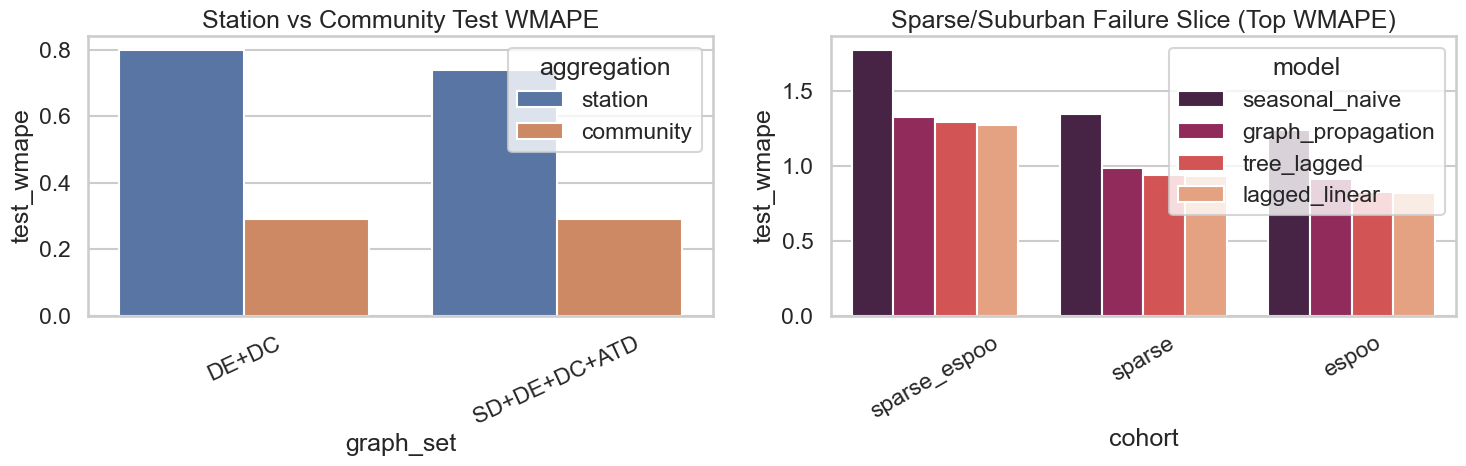

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if {'station', 'community'}.issubset(tradeoff.columns):
    long_tradeoff = tradeoff.melt(id_vars=['graph_set'], value_vars=['station', 'community'], var_name='aggregation', value_name='test_wmape')
    sns.barplot(data=long_tradeoff, x='graph_set', y='test_wmape', hue='aggregation', ax=axes[0], palette='deep')
    axes[0].set_title('Station vs Community Test WMAPE')
    axes[0].tick_params(axis='x', rotation=25)

if not failure_slice.empty:
    sns.barplot(data=failure_slice, x='cohort', y='test_wmape', hue='model', ax=axes[1], palette='rocket')
    axes[1].set_title('Sparse/Suburban Failure Slice (Top WMAPE)')
    axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [7]:
sensitivity = optional_csv('train_eval_3h/sensitivity_summary.csv', required_columns=('sensitivity_axis', 'scope', 'model', 'delta_vs_reference'))

if sensitivity is None:
    rq3_sensitivity = pd.DataFrame()
else:
    rq3_sensitivity = sensitivity.filter(pl.col('scope').is_in(['sparse_vs_dense', 'station_vs_community'])).sort(['scope', 'model']).to_pandas()

rq3_sensitivity

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference
0,threshold,sparse_vs_dense,station,graph_propagation,sparse_quantile=0.25,test_wmape,0.986948,0.722045,0.264902
1,threshold,sparse_vs_dense,station,lagged_linear,sparse_quantile=0.25,test_wmape,0.930064,0.583278,0.346786
2,threshold,sparse_vs_dense,station,seasonal_naive,sparse_quantile=0.25,test_wmape,1.344815,0.876044,0.468771
3,threshold,sparse_vs_dense,station,tree_lagged,sparse_quantile=0.25,test_wmape,0.938595,0.582965,0.355630
4,resolution,station_vs_community,station_community,graph_propagation,aggregation_resolution,test_wmape,0.740800,0.292019,0.448781
5,resolution,station_vs_community,station_community,lagged_linear,aggregation_resolution,test_wmape,0.607830,0.258576,0.349254
6,resolution,station_vs_community,station_community,seasonal_naive,aggregation_resolution,test_wmape,0.909232,0.292019,0.617213
7,resolution,station_vs_community,station_community,tree_lagged,aggregation_resolution,test_wmape,0.608143,0.232901,0.375242


## Threats To Validity (RQ3)

- Community definitions are fixed and may hide station-level heterogeneity within clusters.
- Cohort conclusions depend on sparse threshold choice and city labeling quality.
- Sparse suburban robustness can shift under different temporal splits or exogenous demand shocks.

In [8]:
if {'station', 'community'}.issubset(tradeoff.columns) and not tradeoff.empty:
    best_station = float(tradeoff['station'].min())
    best_community = float(tradeoff['community'].min())
    delta = best_community - best_station
    status = 'supported' if delta < 0 else 'mixed_or_not_supported'
    rationale = f'Best community minus best station test_wmape = {delta:.6f}'
else:
    status = 'insufficient_data'
    rationale = 'Station/community tradeoff table missing required columns.'

pd.DataFrame([{'rq': 'RQ3', 'claim_status': status, 'rationale': rationale}])

,rq,claim_status,rationale
0,RQ3,supported,Best community minus best station test_wmape =...
